# Reproducing Diebold-Yilmaz (2009)

**Diebold, F. X. & Yilmaz, K. (2009).** *Measuring Financial Asset Return and Volatility Spillovers, with Application to Global Equity Markets.*
**The Economic Journal, 119(534), 158–171.**

This notebook reconstructs the full-sample **return** and **volatility** spillover tables of the 2009 paper with `pyconnectedness`, and reproduces the two headline numbers: a **return** spillover index of **35.5 %** (Table 3) and a **volatility** spillover index of about **39.5 %**.

The 2009 paper uses an **orthogonalized (Cholesky)** variance decomposition, that depends on the ordering of the variables, which motivated the construction of the *generalized* decomposition in the paper of Diebold–Yilmaz (2012).



In [1]:
import os
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

from pyconnectedness import static_connectedness, dynamic_connectedness

while not os.path.isdir("examples") and os.path.basename(os.getcwd()):
    os.chdir("..")
# full overview
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)

## Data

Weekly data for **19 global equity markets**, early 1990s to 2007. Two aligned panels: log returns and a weekly volatility measure. One column per market, a `DatetimeIndex` on the rows - the wide, pandas-native layout that `static_connectedness` expects.

In [3]:
returns = pd.read_excel("examples/data/dy2009_returns.xlsx").set_index("date")
volatility = pd.read_excel("examples/data/dy2009_vola.xlsx").set_index("date")

print("Markets:", list(returns.columns))
print("Observations:", len(returns)
      , "| Missing:", int(returns.isna().sum().sum()))
print("Sample:", returns.index.min().date(), "->", returns.index.max().date())

Markets: ['djia', 'ftse', 'fra', 'ger', 'hkg', 'jpn', 'aus', 'idn', 'kor', 'mys', 'phl', 'sgp', 'tai', 'tha', 'arg', 'bra', 'chl', 'mex', 'tur']
Observations: 829 | Missing: 0
Sample: 1992-01-10 -> 2007-11-23


## Table 1 - Descriptive Statistics

Diebold–Yilmaz (2009), Table 1. Two conventions matter for an exact match: kurtosis is reported **raw** (a normal distribution gives 3, not 0), and both skewness and kurtosis use the **population (biased)** estimator. In `scipy` that is `fisher=False` and `bias=True`.

In [4]:
table1 = pd.DataFrame({
    "Mean":     returns.mean(),
    "Median":   returns.median(),
    "Maximum":  returns.max(),
    "Minimum":  returns.min(),
    "Std.Dev.": returns.std(ddof=1),
    "Skewness": pd.Series(stats.skew(returns, bias=True), index=returns.columns),
    "Kurtosis": pd.Series(stats.kurtosis(returns, fisher=False, bias=True), index=returns.columns),
}).T
table1.round(5)

,djia,ftse,fra,ger,hkg,jpn,aus,idn,kor,mys,phl,sgp,tai,tha,arg,bra,chl,mex,tur
Mean,0.00108,0.00037,0.00095,0.00144,0.00134,-0.00051,0.00096,0.00057,0.00047,0.00052,0.00001,0.00090,0.00032,-0.00055,-0.00002,0.00225,0.00112,0.00134,-0.00183
Median,0.00249,0.00127,0.00109,0.00356,0.00256,0.00080,0.00207,0.00163,0.00163,0.00084,0.00036,0.00146,0.00236,0.00080,0.00338,0.00448,0.00102,0.00365,-0.00035
Maximum,0.08015,0.09915,0.10981,0.12942,0.13616,0.11076,0.07044,0.18192,0.17486,0.24264,0.15987,0.18363,0.18671,0.21783,0.24283,0.21935,0.09088,0.17031,0.31551
Minimum,-0.15444,-0.08823,-0.12169,-0.14036,-0.20149,-0.11425,-0.05281,-0.20090,-0.21828,-0.19102,-0.22084,-0.24265,-0.14154,-0.17293,-0.20193,-0.25158,-0.07129,-0.17829,-0.38140
Std.Dev.,0.02085,0.02068,0.02705,0.02948,0.03481,0.02878,0.01611,0.03827,0.04210,0.03220,0.03536,0.03069,0.03566,0.03905,0.05120,0.05548,0.02093,0.03599,0.06477
Skewness,-0.72717,-0.10836,-0.13344,-0.27715,-0.44040,-0.01930,-0.18554,-0.29091,-0.33285,0.13408,-0.31194,-0.61057,0.01157,0.14976,0.02265,-0.29569,0.07717,-0.30595,-0.27740
Kurtosis,7.60941,4.79030,4.15329,5.18385,5.88410,3.96384,3.86330,7.59406,6.20905,11.13712,7.12762,12.99616,5.21114,5.42928,5.46708,5.07689,4.50715,5.35168,7.14676


## Table 2 - Descriptive Statistics - Vola


The same statistics for the volatility panel (Diebold–Yilmaz 2009, Table 2). Volatilities are strongly right-skewed and heavy-tailed, in contrast to the near-symmetric returns above.

In [5]:
table2 = pd.DataFrame({
    "Mean":     volatility.mean(),
    "Median":   volatility.median(),
    "Maximum":  volatility.max(),
    "Minimum":  volatility.min(),
    "Std.Dev.": volatility.std(ddof=1),
    "Skewness": pd.Series(stats.skew(volatility, bias=True), index=volatility.columns),
    "Kurtosis": pd.Series(stats.kurtosis(volatility, fisher=False, bias=True), index=volatility.columns),
}).T
table2.round(5)

,djia,ftse,fra,ger,hkg,jpn,aus,idn,kor,mys,phl,sgp,tai,tha,arg,bra,chl,mex,tur
Mean,0.00042,0.00049,0.00075,0.00083,0.00099,0.00072,0.00023,0.00087,0.00128,0.00085,0.00065,0.00045,0.00079,0.00111,0.00187,0.00210,0.00021,0.00102,0.00317
Median,0.00025,0.00024,0.00043,0.00035,0.00050,0.00050,0.00015,0.00036,0.00064,0.00024,0.00033,0.00020,0.00049,0.00056,0.00085,0.00108,0.00010,0.00053,0.00152
Maximum,0.00595,0.00926,0.01013,0.01629,0.03794,0.00798,0.01045,0.02074,0.01869,0.04592,0.01797,0.01050,0.01376,0.02356,0.03371,0.06133,0.00816,0.02870,0.07689
Minimum,0.00002,0.00001,0.00003,0.00001,0.00002,0.00002,0.00001,0.00000,0.00000,0.00000,0.00000,0.00000,0.00001,0.00003,0.00001,0.00000,0.00000,0.00000,0.00000
Std.Dev.,0.00056,0.00079,0.00104,0.00148,0.00204,0.00079,0.00044,0.00169,0.00192,0.00287,0.00137,0.00081,0.00099,0.00179,0.00327,0.00419,0.00048,0.00180,0.00539
Skewness,4.41977,5.45612,4.25545,4.80717,10.28536,3.56561,16.36687,5.05674,3.88355,10.51185,8.31022,5.33902,4.76813,5.73145,4.99326,7.72435,8.82490,7.87276,6.79783
Kurtosis,30.74238,44.80058,27.33654,34.11062,156.41991,22.41701,361.96651,39.06700,23.23604,137.33461,92.21124,45.60179,45.59744,52.31016,35.89735,82.96087,113.73667,96.06101,73.76338


## The spillover index


Fit a covariance-stationary $\mathrm{VAR}(p)$,

$$x_t = \sum_{i=1}^{p} \Phi_i\, x_{t-i} + \varepsilon_t,
\qquad \varepsilon_t \sim (0,\Sigma),$$

with moving-average representation $x_t = \sum_{h=0}^{\infty} A_h\,\varepsilon_{t-h}$. The 2009 paper identifies **orthogonal** shocks through the Cholesky factor $P$ of $\Sigma$ ($\Sigma = P P'$). The share of the $H$-step forecast-error variance of variable $i$ due to shocks in variable $j$ is

$$\theta_{ij}(H)=
\frac{\sum_{h=0}^{H-1}\big(e_i' A_h P\, e_j\big)^2}
{\sum_{h=0}^{H-1} e_i' A_h \Sigma A_h' e_i}.$$

Because the shocks are orthogonal, each row sums to one, $\sum_j \theta_{ij}(H)=1$. The **total spillover index** is the off-diagonal share of the decomposition,

$$S(H)=\frac{\sum_{i\neq j}\theta_{ij}(H)}{\sum_{i,j}\theta_{ij}(H)}\times 100
=\frac{\sum_{i\neq j}\theta_{ij}(H)}{K}\times 100 .$$

The paper uses a $\mathrm{VAR}(2)$ and a $10$-week-ahead horizon, so `method="orthogonalized"`, `lags=2`, `horizon=10`.

## Table 3 - Return Spillover 

The full spillover table in Diebold–Yilmaz layout: the normalized decomposition (in %), the `FROM` column (shocks received from others), the `TO` row (shocks transmitted to others), and the `NET` row. The bottom-right corner of the table (row `TO_incl_own`) is the **total return spillover index — the paper reports 35.5 %.** This is also exactly the value that `PyConnectedness` obtains.

In [6]:
ret_conn = static_connectedness(returns, horizon=10, method="orthogonalized", lags=2)
print("Total RETURN spillover index:", round(ret_conn.total, 2), "%   (paper: 35.5%)")
ret_conn.table.round(1)

c:\Users\Zoran\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)


Total RETURN spillover index: 35.53 %   (paper: 35.5%)


,djia,ftse,fra,ger,hkg,jpn,aus,idn,kor,mys,phl,sgp,tai,tha,arg,bra,chl,mex,tur,FROM
djia,93.6,1.6,1.5,0.0,0.3,0.2,0.1,0.1,0.2,0.3,0.2,0.2,0.3,0.2,0.1,0.1,0.0,0.5,0.3,6.4
ftse,40.3,55.7,0.7,0.4,0.1,0.5,0.1,0.2,0.2,0.3,0.2,0.0,0.1,0.1,0.1,0.1,0.0,0.4,0.5,44.3
fra,38.3,21.7,37.2,0.1,0.0,0.2,0.3,0.3,0.3,0.2,0.2,0.1,0.1,0.3,0.1,0.1,0.1,0.1,0.3,62.8
ger,40.8,15.9,13.0,27.6,0.1,0.1,0.3,0.4,0.6,0.1,0.3,0.3,0.0,0.2,0.0,0.1,0.0,0.1,0.1,72.4
hkg,15.3,8.7,1.7,1.4,69.9,0.3,0.0,0.1,0.0,0.3,0.1,0.0,0.2,0.9,0.3,0.0,0.1,0.3,0.4,30.1
jpn,12.1,3.1,1.8,0.9,2.3,77.7,0.2,0.3,0.3,0.1,0.2,0.3,0.3,0.1,0.1,0.0,0.0,0.1,0.1,22.3
aus,23.2,6.0,1.3,0.2,6.4,2.3,56.8,0.1,0.4,0.2,0.2,0.2,0.4,0.5,0.1,0.3,0.1,0.6,0.7,43.2
idn,6.0,1.6,1.2,0.7,6.4,1.6,0.4,77.0,0.7,0.4,0.1,0.9,0.2,1.0,0.7,0.1,0.3,0.1,0.4,23.0
kor,8.3,2.6,1.3,0.7,5.6,3.7,1.0,1.2,72.8,0.0,0.0,0.1,0.1,1.3,0.2,0.2,0.1,0.1,0.7,27.2
mys,4.1,2.2,0.6,1.3,10.5,1.5,0.4,6.6,0.5,69.2,0.1,0.1,0.2,1.1,0.1,0.6,0.4,0.2,0.3,30.8


## Table 4 - Volatility spillover 

The same construction on the volatility panel (Diebold–Yilmaz 2009, Table 4). **The paper reports a volatility spillover index of roughly 39.5 %**  - that is  higher than for returns, which is one of the paper's central findings.

In [7]:
vol_conn = static_connectedness(volatility, horizon=10, method="orthogonalized", lags=2)
print("Total VOLATILITY spillover index:", round(vol_conn.total, 1), "%   (paper: ~39.5%)")
vol_conn.table.round(1)

c:\Users\Zoran\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)


Total VOLATILITY spillover index: 39.5 %   (paper: ~39.5%)


,djia,ftse,fra,ger,hkg,jpn,aus,idn,kor,mys,phl,sgp,tai,tha,arg,bra,chl,mex,tur,FROM
djia,63.9,14.9,3.9,1.9,4.9,0.2,1.8,0.3,1.6,0.9,0.4,2.6,0.3,0.1,0.1,0.0,0.1,0.2,2.0,36.1
ftse,22.9,54.5,5.0,1.3,7.4,0.5,2.1,0.3,1.0,0.8,0.1,2.4,0.2,0.2,0.4,0.2,0.1,0.1,0.7,45.5
fra,24.0,32.8,27.3,0.2,5.4,0.2,2.8,0.4,0.3,1.2,0.4,2.4,0.2,0.3,0.6,0.3,0.1,0.1,0.9,72.7
ger,26.9,29.5,13.6,13.7,4.8,0.2,3.9,0.2,0.2,1.3,0.8,2.0,0.2,0.4,0.6,0.3,0.1,0.2,1.0,86.3
hkg,2.0,0.5,0.7,0.0,87.7,0.1,0.1,0.4,1.4,0.5,1.5,3.4,0.6,0.4,0.0,0.1,0.0,0.1,0.3,12.3
jpn,2.7,3.3,0.4,0.7,1.6,82.9,0.1,0.1,0.9,1.1,0.1,1.6,0.3,0.0,0.6,0.3,0.3,0.2,2.8,17.1
aus,8.9,2.2,0.3,0.6,43.9,0.2,34.7,1.2,1.7,1.3,0.1,2.8,0.1,1.0,0.1,0.2,0.2,0.3,0.1,65.3
idn,2.8,0.9,0.3,1.0,6.1,0.3,0.6,71.4,6.9,2.3,2.5,2.8,0.7,0.0,0.0,0.3,0.2,0.2,0.9,28.6
kor,2.5,0.6,0.4,0.4,9.1,1.0,1.0,10.3,67.5,1.3,0.9,2.5,0.8,0.2,0.1,0.1,0.2,0.3,0.8,32.5
mys,1.3,0.6,0.3,0.6,7.2,1.0,0.9,0.8,1.7,70.7,3.1,6.1,0.3,0.5,0.9,0.6,0.1,1.5,1.9,29.3


## Ordering matters: the Cholesky caveat

Because the orthogonalized decomposition depends on the Cholesky ordering, the value of index changes if we permute the columns. Diebold–Yilmaz (2009) address this by recomputing the index for **50 randomly-chosen orderings** and reporting the range.
Here we simply compare the original ordering, the reversed ordering, and one random permutation. The **generalized** decomposition of Diebold–Yilmaz (2012) is order-*invariant*, so it returns the same index no matter how the columns are arranged - shown in the last two rows.

In [8]:
tci_orig = static_connectedness(returns, horizon=10, method="orthogonalized", lags=2).total
tci_rev  = static_connectedness(returns[returns.columns[::-1]], horizon=10, method="orthogonalized", lags=2).total
tci_shuf = static_connectedness(returns.sample(frac=1, axis=1, random_state=1), horizon=10, method="orthogonalized", lags=2).total
tci_gen_orig = static_connectedness(returns, horizon=10, method="generalized", lags=2).total
tci_gen_rev  = static_connectedness(returns[returns.columns[::-1]], horizon=10, method="generalized", lags=2).total

pd.Series({
    "orthogonalized, original order":  tci_orig,
    "orthogonalized, reversed order":  tci_rev,
    "orthogonalized, random order":    tci_shuf,
    "generalized, original order":     tci_gen_orig,
    "generalized, reversed order":     tci_gen_rev,
}, name="TCI %").round(2)

c:\Users\Zoran\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Users\Zoran\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Users\Zoran\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Users\Zoran\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Users\Zoran\AppData\Local\Programs\Python

orthogonalized, original order    35.53
orthogonalized, reversed order    35.44
orthogonalized, random order      35.27
generalized, original order       65.83
generalized, reversed order       65.83
Name: TCI %, dtype: float64

## Dynamic (rolling window) spillovers

The single full-sample number hides time variation that is the point of the paper. Re-estimating the index over a **200-week rolling window** traces the spillover index through time - rising into every major crisis episode of the sample.

c:\Users\Zoran\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Users\Zoran\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Users\Zoran\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Users\Zoran\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Users\Zoran\AppData\Local\Programs\Python

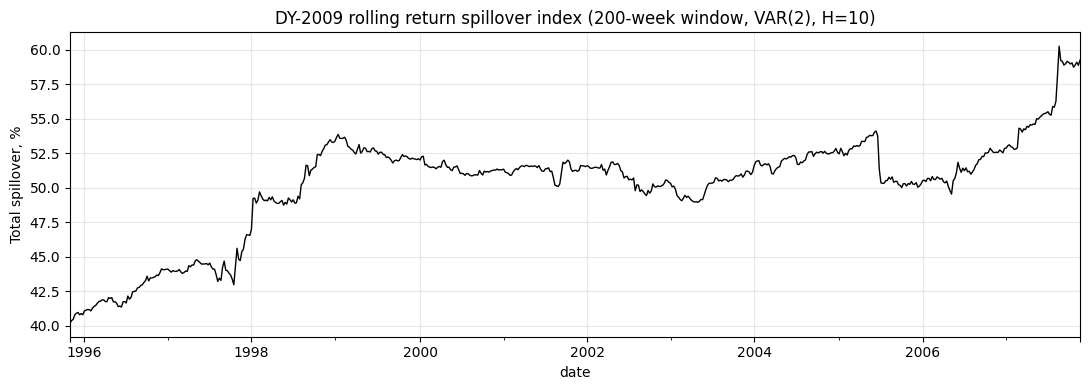

In [9]:
ret_dyn = dynamic_connectedness(returns, window=200, horizon=10, method="orthogonalized", lags=2)

fig, ax = plt.subplots(figsize=(11, 4))
ret_dyn.total.plot(ax=ax, color="black", lw=1)
ax.set_title("DY-2009 rolling return spillover index (200-week window, VAR(2), H=10)")
ax.set_ylabel("Total spillover, %")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

c:\Users\Zoran\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Users\Zoran\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Users\Zoran\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Users\Zoran\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Users\Zoran\AppData\Local\Programs\Python

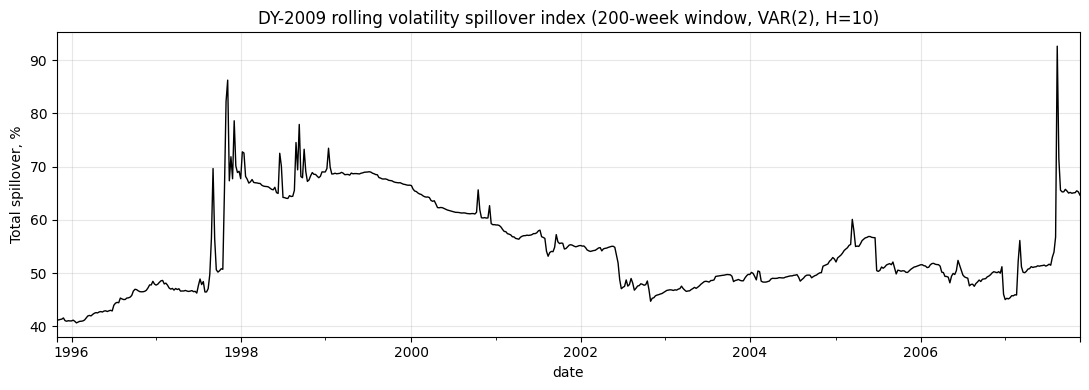

In [10]:

vola_dyn = dynamic_connectedness(volatility, window=200, horizon=10, method="orthogonalized", lags=2)

fig, ax = plt.subplots(figsize=(11, 4))
vola_dyn.total.plot(ax=ax, color="black", lw=1)
ax.set_title("DY-2009 rolling volatility spillover index (200-week window, VAR(2), H=10)")
ax.set_ylabel("Total spillover, %")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Net pairwise directional connectedness

The spillover table is a weighted directed graph. The **net pairwise** measure between two markets is the difference between what $i$ sends to $j$ and what $j$ sends to $i$,

$$C_{ij} = \big(\tilde\theta_{ji} - \tilde\theta_{ij}\big)\times 100,$$

which is antisymmetric ($C_{ij} = -C_{ji}$). In matrix form it is simply $\text{FEVD}^{\top} - \text{FEVD}$. A useful check: each row of $C$ sums to the market's **net** directional spillover, $\sum_{j} C_{ij} = \text{TO}_i - \text{FROM}_i$.

This measure is defined in Diebold–Yilmaz (2012, 2014) and is the building block for the network/heatmap visualisations. This supposed to be the next update - m3. - come back later

In [11]:
net_pairwise = ret_conn.fevd.T - ret_conn.fevd     # C_ij, in percent

# check: row sums of the net-pairwise matrix equal the net directional spillovers
identity_gap = (net_pairwise.sum(axis=1) - ret_conn.net).abs().max()
print("max |row-sum(C) - net directional|:", round(float(identity_gap), 10))

net_pairwise.round(2).T #  --> it has to be transposed to get the sam estructure as before
# so in net terms, connectedness takes place from djia to ftse (C_hat = 38.69) 

# net pairwise is now added to the dynamic.py and static.py

max |row-sum(C) - net directional|: 0.0


,djia,ftse,fra,ger,hkg,jpn,aus,idn,kor,mys,phl,sgp,tai,tha,arg,bra,chl,mex,tur
djia,0.00,-38.69,-36.83,-40.78,-15.00,-11.91,-23.08,-5.94,-8.11,-3.76,-10.93,-16.58,-6.06,-6.05,-11.77,-13.94,-11.76,-21.64,-2.71
ftse,38.69,0.00,-21.07,-15.47,-8.57,-2.52,-5.91,-1.40,-2.43,-1.91,-1.47,-4.77,-1.22,-2.31,-2.08,-1.20,-1.07,-3.17,-1.92
fra,36.83,21.07,0.00,-12.93,-1.64,-1.62,-1.00,-0.86,-1.01,-0.40,-0.01,-0.59,-1.06,-0.72,-1.45,-0.96,-0.88,-1.11,0.10
ger,40.78,15.47,12.93,0.00,-1.30,-0.82,0.11,-0.31,-0.12,-1.14,0.11,-0.60,-1.75,-0.51,-0.05,-0.56,-0.00,-0.36,-0.63
hkg,15.00,8.57,1.64,1.30,0.00,-2.02,-6.33,-6.29,-5.63,-10.24,-7.98,-18.46,-5.15,-6.86,-1.01,-1.27,-3.05,-2.67,-0.19
jpn,11.91,2.52,1.62,0.82,2.02,0.00,-2.17,-1.34,-3.45,-1.45,-0.21,-1.00,-2.47,-0.10,-0.71,-1.37,-0.56,-0.17,-0.76
aus,23.08,5.91,1.00,-0.11,6.33,2.17,0.00,-0.39,-0.52,-0.27,-0.75,-0.22,0.05,-0.31,-1.21,-1.27,-1.32,-0.61,0.07
idn,5.94,1.40,0.86,0.31,6.29,1.34,0.39,0.00,-0.49,-6.14,-7.05,-2.30,-0.19,-6.61,0.25,-0.47,-2.00,-0.11,0.23
kor,8.11,2.43,1.01,0.12,5.63,3.45,0.52,0.49,0.00,-0.50,-0.09,-1.44,-1.94,-3.28,-0.18,-0.31,-0.27,-0.24,0.07
mys,3.76,1.91,0.40,1.14,10.24,1.45,0.27,6.14,0.50,0.00,-2.79,-3.48,-0.81,-2.94,-0.51,-0.10,0.11,-0.71,0.03


In [12]:
vol_conn.pairwise_net

,djia,ftse,fra,ger,hkg,jpn,aus,idn,kor,mys,phl,sgp,tai,tha,arg,bra,chl,mex,tur
djia,0.000000,-8.072680,-20.046793,-25.056694,2.829166,-2.433084,-7.172939,-2.451431,-0.916623,-0.381634,-1.636880,-9.900548,-8.117323,-0.322980,-3.380994,-4.485602,-3.440780,-6.367791,-0.847753
ftse,8.072680,0.000000,-27.865502,-28.206506,6.862676,-2.845553,-0.053321,-0.551858,0.487373,0.224550,-0.220312,-1.719051,-0.201210,-0.480552,-1.122646,-2.124383,-0.655259,-1.247643,-0.994334
fra,20.046793,27.865502,0.000000,-13.452763,4.659169,-0.188351,2.545069,0.171556,-0.078613,0.890490,0.104948,1.808648,-0.146731,-0.081108,-1.048141,-1.100141,-0.553588,-0.572487,0.119618
ger,25.056694,28.206506,13.452763,0.000000,4.715512,-0.540702,3.362236,-0.815285,-0.177184,0.775360,0.404049,1.976342,0.035386,0.027997,0.177721,-0.021741,-0.215877,-0.120640,0.283749
hkg,-2.829166,-6.862676,-4.659169,-4.715512,0.000000,-1.514670,-43.744043,-5.681223,-7.717458,-6.692324,-7.402594,-8.795580,-2.259370,-8.563873,-2.689487,-12.535047,-2.675877,-24.898848,-3.562892
jpn,2.433084,2.845553,0.188351,0.540702,1.514670,0.000000,-0.006250,-0.155743,-0.097261,0.094349,-0.107942,0.781943,-0.452895,-0.168973,0.088056,-0.077247,0.206587,-0.023089,2.439898
aus,7.172939,0.053321,-2.545069,-3.362236,43.744043,0.006250,0.000000,0.637509,0.663223,0.358455,-0.288007,1.988999,-1.117153,0.754763,-1.123538,-3.072583,-3.433854,-4.509668,-1.108778
idn,2.451431,0.551858,-0.171556,0.815285,5.681223,0.155743,-0.637509,0.000000,-3.351906,1.439693,-6.291735,-4.814717,0.156657,-3.593240,-0.225722,-0.720092,-0.883858,-0.134992,0.531302
kor,0.916623,-0.487373,0.078613,0.177184,7.717458,0.097261,-0.663223,3.351906,0.000000,-0.368371,-2.077074,-4.702458,-8.676107,-2.635149,0.015674,-0.177093,-0.071418,-0.247966,-0.286926
mys,0.381634,-0.224550,-0.890490,-0.775360,6.692324,-0.094349,-0.358455,-1.439693,0.368371,0.000000,-3.057532,3.205628,-0.469058,0.156349,-1.280323,-9.353167,-1.711373,-0.872188,-0.800914


In [13]:
ret_conn.pairwise_net#.T

,djia,ftse,fra,ger,hkg,jpn,aus,idn,kor,mys,phl,sgp,tai,tha,arg,bra,chl,mex,tur
djia,0.000000,-38.686530,-36.826660,-40.779732,-14.996288,-11.911020,-23.079099,-5.943972,-8.111522,-3.760050,-10.934648,-16.581970,-6.056764,-6.047812,-11.769407,-13.935490,-11.759272,-21.640840,-2.709563
ftse,38.686530,0.000000,-21.071001,-15.467783,-8.571700,-2.523618,-5.907905,-1.401245,-2.426746,-1.911634,-1.472449,-4.772535,-1.222790,-2.308703,-2.083374,-1.198017,-1.070799,-3.174527,-1.915698
fra,36.826660,21.071001,0.000000,-12.928494,-1.637909,-1.624507,-1.001984,-0.860447,-1.010045,-0.396660,-0.010732,-0.586578,-1.059037,-0.715680,-1.453175,-0.957754,-0.882736,-1.113487,0.098623
ger,40.779732,15.467783,12.928494,0.000000,-1.300337,-0.821507,0.110151,-0.313947,-0.117546,-1.137367,0.106204,-0.595149,-1.747060,-0.514011,-0.054509,-0.560755,-0.000399,-0.363324,-0.630029
hkg,14.996288,8.571700,1.637909,1.300337,0.000000,-2.019708,-6.334891,-6.292845,-5.630407,-10.237020,-7.977072,-18.458061,-5.146190,-6.856811,-1.007236,-1.270094,-3.052889,-2.671655,-0.194786
jpn,11.911020,2.523618,1.624507,0.821507,2.019708,0.000000,-2.173728,-1.341347,-3.448957,-1.445872,-0.210268,-1.003949,-2.474648,-0.097781,-0.712013,-1.365516,-0.564442,-0.165582,-0.757590
aus,23.079099,5.907905,1.001984,-0.110151,6.334891,2.173728,0.000000,-0.385766,-0.523363,-0.268723,-0.750373,-0.215424,0.049852,-0.308180,-1.207470,-1.266778,-1.320990,-0.609060,0.072363
idn,5.943972,1.401245,0.860447,0.313947,6.292845,1.341347,0.385766,0.000000,-0.488456,-6.140796,-7.051628,-2.304722,-0.186804,-6.609144,0.247053,-0.471224,-1.998799,-0.105648,0.225195
kor,8.111522,2.426746,1.010045,0.117546,5.630407,3.448957,0.523363,0.488456,0.000000,-0.498444,-0.085228,-1.437016,-1.937474,-3.280775,-0.177043,-0.305746,-0.265510,-0.239735,0.067008
mys,3.760050,1.911634,0.396660,1.137367,10.237020,1.445872,0.268723,6.140796,0.498444,0.000000,-2.794739,-3.481426,-0.808872,-2.941438,-0.513196,-0.100125,0.107821,-0.711635,0.029951


## Summary

| Result | `pyconnectedness` | Diebold–Yilmaz (2009) |
|---|---|---|
| Return spillover index (Table 3) | 35.5% | **35.5 %** |
| Volatility spillover index (Table 4) | 39,5% | **≈ 39.5 %** |

Both numbers reproduce with an orthogonalized VAR(2) and a 10-week horizon. The ordering check shows why the 2009 index is ordering-dependent and motivates the generalized decomposition shown in `exeercises/replicate_dy2012.ipynb`.